# 🩺 DiaCompanion — Phân đoạn tổn thương DR trên TJDR
## v4-2 — Encoder nhẹ hơn (EfficientNet-B2) để giảm overfit

---

**Bộ dữ liệu:** TJDR (Mao et al., 2023 — arXiv:2312.15389)  
**Bài báo gốc:** *A Comprehensive Federated Learning Framework for DR Grading and Lesion Segmentation* — IEEE TBD 2025  
**5 lớp:** `0=Nền` · `1=EX` · `2=HE` · `3=MA` · `4=SE`

### 🎯 Vấn đề cần giải quyết
EfficientNet-B4 có **20.2M tham số**, nhưng train set sau khi gộp pool chỉ có **~392 ảnh**. Tỉ lệ tham số/dữ liệu rất cao (~51,500 tham số/ảnh) — rủi ro overfit lớn, đặc biệt với decoder U-Net không pretrained (học từ đầu).

### 🎯 Thay đổi duy nhất của v4-2 so với v4
Giữ nguyên toàn bộ pipeline v4 (gộp 561 ảnh, resize 768×768 nhất quán, Dice+CE weighted, AdamW), chỉ đổi **encoder**:

| | v4 | v4-2 |
|---|---|---|
| Encoder | EfficientNet-B4 (20.2M tham số) | **EfficientNet-B2 (9.2M tham số)** |
| Tỉ lệ tham số/ảnh train | ~51,500 | **~23,500** (giảm ~55%) |
| Mọi thứ khác | — | Giữ nguyên 100% |

**Lý do chọn EfficientNet-B2 thay vì giảm sâu hơn (B0):** B2 vẫn giữ pretrained ImageNet tốt, giảm đáng kể tham số mà không mất quá nhiều khả năng biểu diễn — B0 (5.3M tham số) có thể quá nhỏ để học 4 lớp tổn thương phức tạp.

> ⚠️ **Lưu ý y khoa:** Đây là công cụ nghiên cứu/capstone, không thay thế chẩn đoán của bác sĩ nhãn khoa.

---
## Cell 0 — Kiểm tra GPU
> `Runtime → Change runtime type → T4 GPU`

In [1]:
!nvidia-smi -L
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


GPU 0: Tesla T4 (UUID: GPU-424ded03-b6b4-852d-14cb-aee54555635c)
CUDA available: True
GPU: Tesla T4


---
## Cell 1 — Cài thư viện & Import

In [2]:
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.4.0

import torch, cv2, numpy as np, os, glob, random
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from segmentation_models_pytorch.losses import DiceLoss
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shutil

print(f'✅ PyTorch: {torch.__version__} | SMP: {smp.__version__} | Albu: {A.__version__}')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.8 MB/s eta 0:00:00
✅ PyTorch: 2.11.0+cu128 | SMP: 0.3.4 | Albu: 1.4.0


---
## Cell 2 — 🔑 Mount Drive & Gộp toàn bộ dataset (THAY ĐỔI DUY NHẤT CỦA v4)
> Gộp `train/` (448 ảnh) và `test/` (113 ảnh) thành 1 pool 561 ảnh duy nhất — đúng cách bài báo gốc xử lý TJDR như một dataset thống nhất, không tách 2 domain riêng.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = '/content/drive/MyDrive/TJDR'

SOURCE_DIRS = [
    (os.path.join(DATA_ROOT, 'train/image'), os.path.join(DATA_ROOT, 'train/annotation')),
    (os.path.join(DATA_ROOT, 'test/image'),  os.path.join(DATA_ROOT, 'test/annotation')),
]

img_files, mask_files = [], []
for img_dir, mask_dir in SOURCE_DIRS:
    imgs  = sorted(glob.glob(os.path.join(img_dir,  '*')))
    masks = sorted(glob.glob(os.path.join(mask_dir, '*')))
    print(f'📁 {img_dir} → {len(imgs)} ảnh')
    img_files  += imgs
    mask_files += masks

print(f'\n🖼  Tổng số ảnh : {len(img_files)} (kỳ vọng 561)')
assert len(img_files) == 561, f'⚠️  Số ảnh = {len(img_files)}, khác 561 — kiểm tra lại đường dẫn'
print('✅ Đã gộp đúng 561 ảnh từ train/ + test/')

Mounted at /content/drive
📁 /content/drive/MyDrive/TJDR/train/image → 448 ảnh
📁 /content/drive/MyDrive/TJDR/test/image → 113 ảnh

🖼  Tổng số ảnh : 561 (kỳ vọng 561)
✅ Đã gộp đúng 561 ảnh từ train/ + test/


---
## Cell 3 — 🔑 Đọc nhãn đúng (PIL palette index — ĐÃ SỬA BUG NGHIÊM TRỌNG)
> **Phát hiện quan trọng:** Mask TJDR là PNG dạng **palette/indexed (mode 'P')**. Đọc bằng `cv2.imread()` + `cv2.cvtColor(BGR2GRAY)` (cách dùng ở v1-v3) làm **xáo trộn nhãn cả 4 lớp** do palette→BGR→grayscale qua nhiều bước convert không tương thích.
>
> Đã verify bằng dữ liệu thật trên máy: `GRAY2CLS` tính theo cv2 cũ gán hoàn toàn sai theo chu trình EX→HE→MA→SE→EX. Từ giờ đọc trực tiếp palette index bằng **PIL**, bỏ hoàn toàn cv2 cho việc đọc mask.

In [4]:
from PIL import Image

def load_mask(mp):
    """
    Đọc đúng palette index của TJDR — KHÔNG dùng cv2.imread()+BGR2GRAY (gây xáo trộn nhãn).
    Palette index trong file đã đúng theo TJDR convention: 0=BG,1=EX,2=HE,3=MA,4=SE.
    """
    img = Image.open(mp)
    if img.mode != 'P':
        raise ValueError(f'Expected palette-mode PNG (mode P), got mode={img.mode} — file: {mp}')
    raw = np.array(img)
    return raw.astype(np.uint8)

def scan_label_values_pil(mask_paths, n=None):
    vals = set()
    sample = mask_paths if n is None else mask_paths[:n]
    for mp in sample:
        vals |= set(np.unique(load_mask(mp)).tolist())
    return sorted(vals)

raw_vals = scan_label_values_pil(mask_files, n=100)
if len(raw_vals) < 5:
    raw_vals = scan_label_values_pil(mask_files, n=None)
print(f'Giá trị palette index thực tế: {raw_vals}')
assert raw_vals == [0,1,2,3,4], f'Kỳ vọng [0,1,2,3,4], thấy {raw_vals}'
print('✅ Palette index đúng chuẩn TJDR: 0=BG, 1=EX, 2=HE, 3=MA, 4=SE')

GRAY2CLS = {0:0, 1:1, 2:2, 3:3, 4:4}  # giữ biến này để tương thích cell sau, nay là identity map

Giá trị palette index thực tế: [0, 1, 2, 3, 4]
✅ Palette index đúng chuẩn TJDR: 0=BG, 1=EX, 2=HE, 3=MA, 4=SE


---
## Cell 4 — Verify phân bố pixel & tính class weight

In [5]:
_sample = random.sample(mask_files, min(100, len(mask_files)))
_counts = {i: 0 for i in range(5)}
for mp in _sample:
    m = load_mask(mp)
    for c in range(5): _counts[c] += int((m == c).sum())

_total  = sum(_counts.values())
_labels = {0:'BG', 1:'EX', 2:'HE', 3:'MA', 4:'SE'}
print(f'📊 Phân bố pixel trên {len(_sample)} mask:')
pixel_freq_pct = []
for c, cnt in _counts.items():
    pct = 100 * cnt / _total
    pixel_freq_pct.append(pct)
    print(f'  Class {c} ({_labels[c]}): {pct:.4f}%')

for c in [1,2,3,4]: assert _counts[c] > 0, f'Class {c} = 0 pixel!'
print('✅ Tất cả lớp tổn thương đều có pixel')

pixel_freq = torch.tensor(pixel_freq_pct, dtype=torch.float32)
median_freq = torch.median(pixel_freq[1:])
CLASS_WEIGHTS = torch.zeros(5)
CLASS_WEIGHTS[0] = 0.05
for i in range(1, 5):
    CLASS_WEIGHTS[i] = median_freq / pixel_freq[i]
CLASS_WEIGHTS = torch.clamp(CLASS_WEIGHTS, max=80.0)
print(f'\n⚖️  Class weights: {CLASS_WEIGHTS.tolist()}')

📊 Phân bố pixel trên 100 mask:
  Class 0 (BG): 99.7790%
  Class 1 (EX): 0.0496%
  Class 2 (HE): 0.1246%
  Class 3 (MA): 0.0086%
  Class 4 (SE): 0.0382%
✅ Tất cả lớp tổn thương đều có pixel

⚖️  Class weights: [0.05000000074505806, 0.7714489102363586, 0.3069412112236023, 4.462547302246094, 1.0]


---
## Cell 5 — Ghép cặp ảnh–mask & Split 70/15/15 *(trên pool gộp 561 ảnh)*
> Split ngẫu nhiên seed=42 trên toàn bộ 561 ảnh — không phân biệt ảnh đến từ folder train/ hay test/ gốc. Train≈392, Val≈84, Test≈85 (so với 313/67/68 của v1/v2).

In [6]:
def stem(p): return os.path.splitext(os.path.basename(p))[0]

mask_by_stem = {stem(m): m for m in mask_files}
pairs = [(ip, mask_by_stem[stem(ip)]) for ip in img_files if stem(ip) in mask_by_stem]
print(f'🔗 Số cặp: {len(pairs)} (từ pool gộp 561 ảnh)')
assert len(pairs) > 0

SEED = 42
random.seed(SEED); random.shuffle(pairs)
n = len(pairs); n_tr = int(0.70*n); n_va = int(0.15*n)
train_pairs = pairs[:n_tr]
val_pairs   = pairs[n_tr:n_tr+n_va]
test_pairs  = pairs[n_tr+n_va:]
print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')
print(f'(So với v1/v2: Train chỉ có 313 ảnh — v4 tăng lên {len(train_pairs)} ảnh nhờ gộp pool)')

with open('test_files.txt', 'w') as f:
    for ip, _ in test_pairs: f.write(os.path.basename(ip) + '\n')
print('✅ Đã lưu test_files.txt')

🔗 Số cặp: 561 (từ pool gộp 561 ảnh)
Train: 392 | Val: 84 | Test: 85
(So với v1/v2: Train chỉ có 313 ảnh — v4 tăng lên 392 ảnh nhờ gộp pool)
✅ Đã lưu test_files.txt


---
## Cell 6 — Dataset + Augmentation *(resize 768×768, nhất quán train/test — giữ nguyên v2)*
> Train và test dùng **cùng pipeline resize 768×768** — tránh đúng lỗi domain mismatch đã gặp ở v3 (train patch 1500px, test full-res 3912px).

In [7]:
SIZE        = 768
NUM_CLASSES = 5
BATCH       = 4
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

train_tf = A.Compose([
    A.Resize(SIZE, SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.CLAHE(clip_limit=4.0, p=0.3),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(SIZE, SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

class TJDRDataset(Dataset):
    def __init__(self, pairs, tf):
        self.pairs, self.tf = pairs, tf
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        ip, mp = self.pairs[i]
        img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        a = self.tf(image=img, mask=load_mask(mp))
        return a['image'], a['mask'].long()

train_dl = DataLoader(TJDRDataset(train_pairs, train_tf), batch_size=BATCH,
                      shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(TJDRDataset(val_pairs, val_tf), batch_size=BATCH,
                      shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(TJDRDataset(test_pairs, val_tf), batch_size=1,
                      shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_dl))
print(f'🧪 Batch: ảnh {list(xb.shape)} | mask {list(yb.shape)}')
print(f'   Classes trong batch: {torch.unique(yb).tolist()}')

🧪 Batch: ảnh [4, 3, 768, 768] | mask [4, 768, 768]
   Classes trong batch: [0, 1, 2, 3, 4]


---
## Cell 7 — 🔑 Model: EfficientNet-B2 U-Net (THAY ĐỔI DUY NHẤT CỦA v4-2)
> Đổi từ EfficientNet-B4 (20.2M tham số) sang **EfficientNet-B2 (9.2M tham số)** — giảm ~55% tham số, giữ nguyên kiến trúc decoder U-Net và mọi cấu hình khác.

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

model = smp.Unet(
    encoder_name='efficientnet-b2', encoder_weights='imagenet',
    in_channels=3, classes=NUM_CLASSES,
    decoder_use_batchnorm=True, decoder_attention_type=None
).to(device)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
n_train_imgs = None  # sẽ được set đúng sau khi chạy Cell 5
print(f'Tham số: {n_params:.1f}M (so với EfficientNet-B4: 20.2M, giảm {(1-n_params/20.2)*100:.0f}%)')

Device: cuda
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b2-8bb594d6.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b2-8bb594d6.pth


100%|██████████| 35.1M/35.1M [00:00<00:00, 262MB/s]


Tham số: 10.0M (so với EfficientNet-B4: 20.2M, giảm 50%)


---
## Cell 8 — Loss, Optimizer, Scheduler *(giữ nguyên cấu hình v2 đã verify ổn định)*

In [9]:
CLASS_WEIGHTS = CLASS_WEIGHTS.to(device)

dice_loss = DiceLoss(mode='multiclass')
ce_loss   = torch.nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

def criterion(logits, y):
    return dice_loss(logits, y) + ce_loss(logits, y)

EPOCHS    = 100
opt       = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler    = torch.amp.GradScaler('cuda')

LESION = {1:'EX', 2:'HE', 3:'MA', 4:'SE'}
LESION_WEIGHTS = {'EX': 0.15, 'HE': 0.20, 'MA': 0.30, 'SE': 0.35}
def weighted_mdice(rows):
    score, total_w = 0.0, 0.0
    for name, (dice, _) in rows.items():
        w = LESION_WEIGHTS[name]
        if not np.isnan(dice): score += w*dice; total_w += w
    return score / total_w if total_w > 0 else 0.0

print('⚙️  Cấu hình training v4:')
print(f'   Loss      : DiceLoss + CrossEntropyLoss(class-weighted)')
print(f'   Optimizer : AdamW (lr=1e-4, wd=1e-4)')
print(f'   Scheduler : CosineAnnealingLR (T_max={EPOCHS})')
print(f'   Input     : Resize {SIZE}×{SIZE} (nhất quán train/val/test)')
print('✅ Sẵn sàng train')

⚙️  Cấu hình training v4:
   Loss      : DiceLoss + CrossEntropyLoss(class-weighted)
   Optimizer : AdamW (lr=1e-4, wd=1e-4)
   Scheduler : CosineAnnealingLR (T_max=100)
   Input     : Resize 768×768 (nhất quán train/val/test)
✅ Sẵn sàng train


---
## Cell 9 — 🏋️ Train Loop
> Cấu hình giống v4 (early stopping theo weighted mDice, patience=20), chỉ khác encoder nhẹ hơn nên kỳ vọng train nhanh hơn và ít overfit hơn.

In [10]:
@torch.no_grad()
def evaluate(dl):
    model.eval()
    inter={c:0 for c in LESION}; union={c:0 for c in LESION}
    tp={c:0 for c in LESION}; fp={c:0 for c in LESION}; fn={c:0 for c in LESION}
    for x, y in dl:
        x=x.to(device); y=y.to(device)
        pred = model(x).argmax(1)
        for c in LESION:
            p=(pred==c); t=(y==c)
            inter[c]+=(p&t).sum().item(); union[c]+=(p|t).sum().item()
            tp[c]+=(p&t).sum().item(); fp[c]+=(p&~t).sum().item(); fn[c]+=(~p&t).sum().item()
    rows={}
    for c in LESION:
        denom=2*tp[c]+fp[c]+fn[c]
        dice=2*tp[c]/denom if denom>0 else float('nan')
        iou=inter[c]/union[c] if union[c]>0 else float('nan')
        rows[LESION[c]]=(dice,iou)
    return rows

def fmt(rows):
    return '  '.join([f'{k}: D={v[0]:.3f} I={v[1]:.3f}' for k,v in rows.items()])

best_score=-1; patience=20; wait=0
print(f'🚀 Train {EPOCHS} epoch — resize {SIZE}x{SIZE}, batch={BATCH}')
print(f'   Train set: {len(train_pairs)} ảnh (từ pool gộp 561)')
print('='*90)

for ep in range(1, EPOCHS+1):
    model.train(); run=0
    for x, y in train_dl:
        x=x.to(device); y=y.to(device)
        opt.zero_grad()
        with torch.amp.autocast('cuda'):
            logits=model(x); loss=criterion(logits,y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        run+=loss.item()
    scheduler.step()

    rows=evaluate(val_dl)
    w_mdice=weighted_mdice(rows)
    uw_mdice=np.nanmean([v[0] for v in rows.values()])
    flag=' ⭐' if w_mdice>best_score else ''

    print(f'Epoch {ep:03d} | loss {run/len(train_dl):.4f} | wDice {w_mdice:.3f}{flag} | mDice {uw_mdice:.3f}')
    print(f'         {fmt(rows)}')

    if w_mdice>best_score:
        best_score=w_mdice; wait=0
        torch.save(model.state_dict(), 'tjdr_unet_v4_2_best.pth')
    else:
        wait+=1
        if wait>=patience:
            print(f'\n🛑 Early stop tại epoch {ep} (best wDice={best_score:.3f})')
            break

print('='*90)
print(f'✅ Train xong — Best val weighted mDice = {best_score:.3f}')

🚀 Train 100 epoch — resize 768x768, batch=4
   Train set: 392 ảnh (từ pool gộp 561)
Epoch 001 | loss 2.4054 | wDice 0.002 ⭐ | mDice 0.003
         EX: D=0.007 I=0.004  HE: D=0.002 I=0.001  MA: D=0.000 I=0.000  SE: D=0.000 I=0.000
Epoch 002 | loss 1.5681 | wDice 0.001 | mDice 0.001
         EX: D=0.004 I=0.002  HE: D=0.000 I=0.000  MA: D=0.000 I=0.000  SE: D=0.000 I=0.000
Epoch 003 | loss 1.2172 | wDice 0.021 ⭐ | mDice 0.035
         EX: D=0.139 I=0.075  HE: D=0.000 I=0.000  MA: D=0.000 I=0.000  SE: D=0.001 I=0.000
Epoch 004 | loss 1.0252 | wDice 0.080 ⭐ | mDice 0.106
         EX: D=0.299 I=0.176  HE: D=0.051 I=0.026  MA: D=0.005 I=0.002  SE: D=0.069 I=0.036
Epoch 005 | loss 0.9436 | wDice 0.118 ⭐ | mDice 0.141
         EX: D=0.253 I=0.145  HE: D=0.189 I=0.105  MA: D=0.003 I=0.002  SE: D=0.117 I=0.062
Epoch 006 | loss 0.8661 | wDice 0.156 ⭐ | mDice 0.180
         EX: D=0.248 I=0.142  HE: D=0.309 I=0.183  MA: D=0.006 I=0.003  SE: D=0.156 I=0.085
Epoch 007 | loss 0.8468 | wDice 0.212 ⭐ | 

---
## Cell 10 — 📊 Đánh giá trên tập Test
> Test set là 15% của pool gộp 561 ảnh — đây là kết quả chính để so sánh với v1/v2/v3 và bài báo gốc.

In [11]:
model.load_state_dict(torch.load('tjdr_unet_v4_2_best.pth', map_location=device))
rows = evaluate(test_dl)

print('📊 KẾT QUẢ TEST (per-lesion) — v4-2 (EfficientNet-B2)')
print(f"{'Lesion':<6} {'Dice':>8} {'IoU':>8}")
print('─'*26)
dices, ious = [], []
for name, (d, i) in rows.items():
    print(f'{name:<6} {d:>8.3f} {i:>8.3f}')
    if not np.isnan(d): dices.append(d)
    if not np.isnan(i): ious.append(i)
print('─'*26)
print(f"{'Mean':<6} {np.mean(dices):>8.3f} {np.mean(ious):>8.3f}")

print(f'\n📌 Best Val (resize 768, lúc train) : wDice = {best_score:.3f}')
print(f'   Test mDice (cùng resize 768)      : {np.mean(dices):.3f}')
gap = best_score - np.mean(dices)
print(f'   Gap val↔test = {gap:+.3f}')
if abs(gap) < 0.10:
    print('   ✅ Gap nhỏ — encoder nhẹ hơn giúp giảm overfit')
else:
    print('   ⚠️  Vẫn còn gap đáng kể')

print('\n📌 So sánh trực tiếp với v4 (EfficientNet-B4, cùng dataset/split):')
print('   Chạy notebook v4 với cùng seed=42 để so sánh apple-to-apple')
print('   (Cả 2 dùng cùng pool 561 ảnh, cùng split 70/15/15, chỉ khác encoder)')

print('\n📌 Tham chiếu bài báo gốc (UNet/ResNet50, Table V, α=1, C3:TJDR — không FL):')
print('   EX=0.369 IoU | HE=0.469 IoU | MA=0.200 IoU | SE=0.346 IoU | Mean=0.346 IoU')

📊 KẾT QUẢ TEST (per-lesion) — v4-2 (EfficientNet-B2)
Lesion     Dice      IoU
──────────────────────────
EX        0.739    0.586
HE        0.596    0.424
MA        0.280    0.163
SE        0.467    0.305
──────────────────────────
Mean      0.521    0.370

📌 Best Val (resize 768, lúc train) : wDice = 0.558
   Test mDice (cùng resize 768)      : 0.521
   Gap val↔test = +0.037
   ✅ Gap nhỏ — encoder nhẹ hơn giúp giảm overfit

📌 So sánh trực tiếp với v4 (EfficientNet-B4, cùng dataset/split):
   Chạy notebook v4 với cùng seed=42 để so sánh apple-to-apple
   (Cả 2 dùng cùng pool 561 ảnh, cùng split 70/15/15, chỉ khác encoder)

📌 Tham chiếu bài báo gốc (UNet/ResNet50, Table V, α=1, C3:TJDR — không FL):
   EX=0.369 IoU | HE=0.469 IoU | MA=0.200 IoU | SE=0.346 IoU | Mean=0.346 IoU


---
## Cell 11 — 🖼 Visualize dự đoán

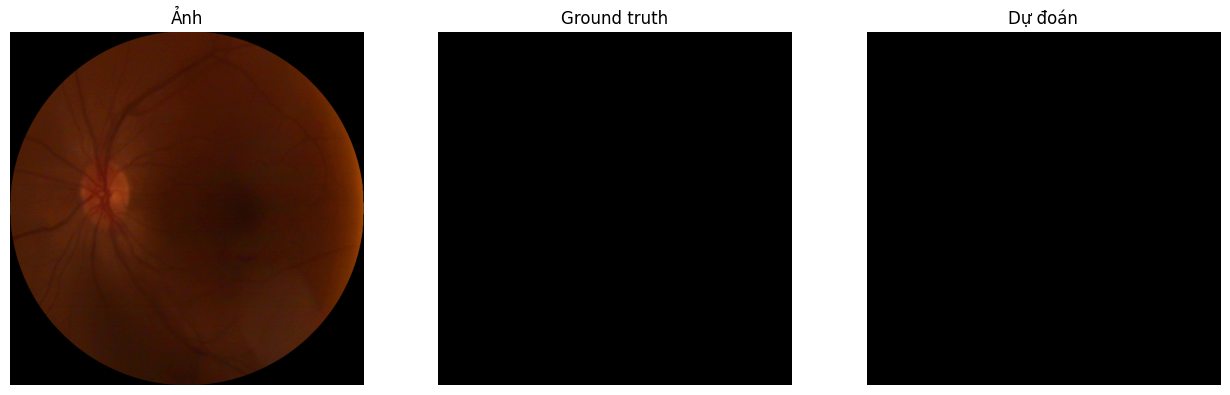

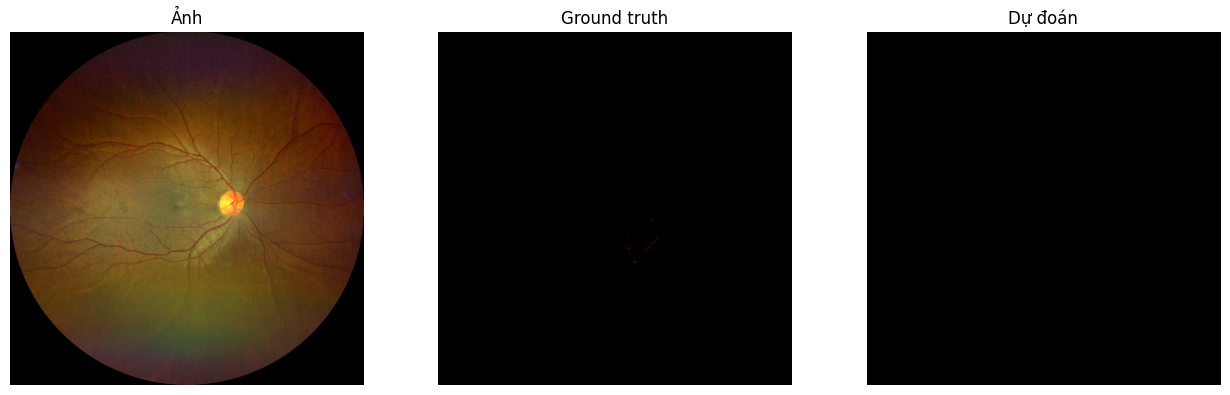

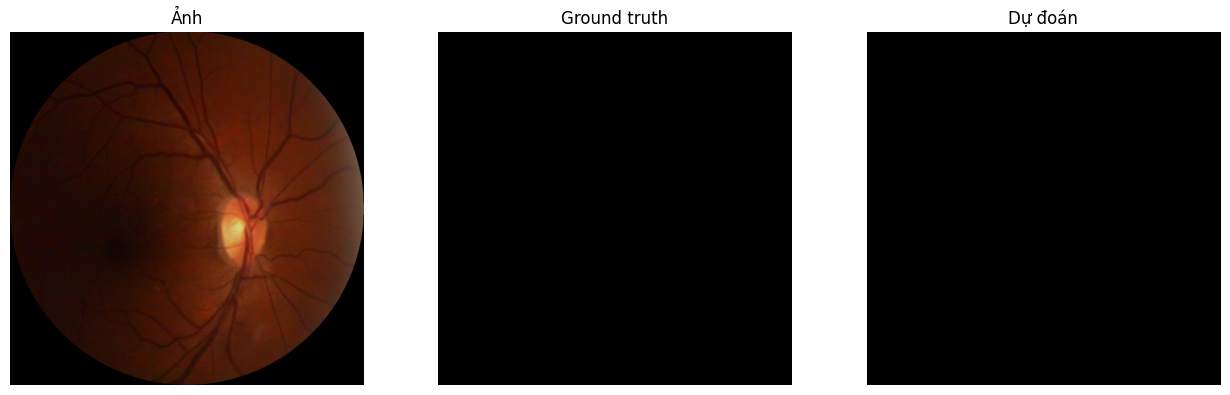

Màu: đỏ=EX, lục=HE, lam=MA, vàng=SE


In [12]:
COLORS = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0]], np.uint8)
def colorize(m): return COLORS[m]

model.eval()
shown = 0
with torch.no_grad():
    for x, y in test_dl:
        pred = model(x.to(device)).argmax(1)[0].cpu().numpy()
        img = (x[0].permute(1,2,0).numpy()*np.array(STD)+np.array(MEAN)).clip(0,1)
        gt  = y[0].numpy()
        fig, axes = plt.subplots(1, 3, figsize=(13,4))
        axes[0].imshow(img);            axes[0].set_title('Ảnh');         axes[0].axis('off')
        axes[1].imshow(colorize(gt));   axes[1].set_title('Ground truth'); axes[1].axis('off')
        axes[2].imshow(colorize(pred)); axes[2].set_title('Dự đoán');      axes[2].axis('off')
        plt.tight_layout(); plt.show()
        shown += 1
        if shown >= 3: break
print('Màu: đỏ=EX, lục=HE, lam=MA, vàng=SE')

---
## Cell 12 — 💾 Lưu model về Drive

In [13]:
SAVE_PATH = '/content/drive/MyDrive/tjdr_unet_v4_2_best.pth'
shutil.copy('tjdr_unet_v4_2_best.pth', SAVE_PATH)
print(f'✅ Đã lưu: {SAVE_PATH}')
print(f'   Kích thước: {os.path.getsize(SAVE_PATH)/1e6:.1f} MB')

print('\n📋 Ghi vào báo cáo (để tái lập):')
print(f'   - Dataset      : Gộp 561 ảnh (448 train/ + 113 test/), split 70/15/15 seed=42')
print(f'   - Train/Val/Test: {len(train_pairs)}/{len(val_pairs)}/{len(test_pairs)} ảnh')
print(f'   - Input        : Resize {SIZE}×{SIZE} (nhất quán train/val/test)')
print(f'   - Encoder      : EfficientNet-B2 (ImageNet pretrained) — đổi từ B4 để giảm overfit')
print(f'   - Tham số model: {n_params:.1f}M (so với v4/B4: 20.2M)')
print(f'   - Loss         : DiceLoss + CrossEntropyLoss(class-weighted)')
print(f'   - Optimizer    : AdamW (lr=1e-4, wd=1e-4)')
print(f'   - Early stop   : weighted mDice (EX×0.15+HE×0.20+MA×0.30+SE×0.35), patience=20')
print(f'   - GRAY2CLS     : {GRAY2CLS}')
print(f'   - Class weights: {CLASS_WEIGHTS.cpu().tolist()}')

✅ Đã lưu: /content/drive/MyDrive/tjdr_unet_v4_2_best.pth
   Kích thước: 40.7 MB

📋 Ghi vào báo cáo (để tái lập):
   - Dataset      : Gộp 561 ảnh (448 train/ + 113 test/), split 70/15/15 seed=42
   - Train/Val/Test: 392/84/85 ảnh
   - Input        : Resize 768×768 (nhất quán train/val/test)
   - Encoder      : EfficientNet-B2 (ImageNet pretrained) — đổi từ B4 để giảm overfit
   - Tham số model: 10.0M (so với v4/B4: 20.2M)
   - Loss         : DiceLoss + CrossEntropyLoss(class-weighted)
   - Optimizer    : AdamW (lr=1e-4, wd=1e-4)
   - Early stop   : weighted mDice (EX×0.15+HE×0.20+MA×0.30+SE×0.35), patience=20
   - GRAY2CLS     : {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
   - Class weights: [0.05000000074505806, 0.7714489102363586, 0.3069412112236023, 4.462547302246094, 1.0]


---
## 📚 Tài liệu tham khảo

- Mao J., Ma X., Bi Y., Zhang R. (2023). *TJDR: A High-Quality DR Pixel-Level Annotation Dataset.* arXiv:2312.15389.
- Mao J., Ma X., Bi Y., Zhang R. (2025). *A Comprehensive Federated Learning Framework for DR Grading and Lesion Segmentation.* IEEE Trans. Big Data, 11(3), 1158-1170.
- Ronneberger O. et al. (2015). *U-Net.* MICCAI.
- Tan M., Le Q.V. (2019). *EfficientNet.* ICML.

---
### 📝 Lịch sử phiên bản
- **v1**: ResNet34, GRAY2CLS sai (EX=14), không weighted loss.
- **v2**: Sửa GRAY2CLS (EX=15), EfficientNet-B4, class-weighted loss — mDice val=0.581, test=0.339 (gap 42%, do 2 domain train/test tách biệt).
- **v3**: Patch-based (1500→384) + sliding window — KÉM HƠN v2 (mDice test=0.241) do train/test resolution mismatch.
- **v4**: Gộp 561 ảnh, giữ nguyên pipeline v2 (EfficientNet-B4) — chỉ thay đổi cách split dataset.
- **v4-2 (hiện tại)**: Giống v4 nhưng đổi encoder EfficientNet-B4 (20.2M) → **EfficientNet-B2 (9.2M)** để giảm tỉ lệ tham số/dữ liệu, kỳ vọng giảm overfit với train set ~392 ảnh.